In [42]:
from google.colab import drive

drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [43]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [44]:
!cp /content/gdrive/MyDrive/'Colab Notebooks'/kaggle.json ~/.kaggle/

In [45]:
!chmod 600 /content/gdrive/MyDrive/'Colab Notebooks'/kaggle.json
!kaggle datasets download hellbuoy/car-price-prediction

Dataset URL: https://www.kaggle.com/datasets/hellbuoy/car-price-prediction
License(s): unknown
car-price-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)


In [46]:
! unzip car-price-prediction.zip

Archive:  car-price-prediction.zip
  inflating: CarPrice_Assignment.csv  
  inflating: Data Dictionary - carprices.xlsx  


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [49]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [50]:
df.drop(['car_ID', 'CarName', 'aspiration'], axis=1, inplace=True)

In [51]:
df.head()

,symboling,fueltype,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,gas,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,gas,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,gas,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,gas,four,sedan,fwd,front,99.8,176.6,66.2,54.3,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,gas,four,sedan,4wd,front,99.4,176.6,66.4,54.3,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   fueltype          205 non-null    object 
 2   doornumber        205 non-null    object 
 3   carbody           205 non-null    object 
 4   drivewheel        205 non-null    object 
 5   enginelocation    205 non-null    object 
 6   wheelbase         205 non-null    float64
 7   carlength         205 non-null    float64
 8   carwidth          205 non-null    float64
 9   carheight         205 non-null    float64
 10  curbweight        205 non-null    int64  
 11  enginetype        205 non-null    object 
 12  cylindernumber    205 non-null    object 
 13  enginesize        205 non-null    int64  
 14  fuelsystem        205 non-null    object 
 15  boreratio         205 non-null    float64
 16  stroke            205 non-null    float64
 1

In [53]:
df['cylindernumber']

,cylindernumber
0,four
1,four
2,six
3,four
4,five
...,...
200,four
201,four
202,six
203,six


In [54]:
df['fuelsystem']

,fuelsystem
0,mpfi
1,mpfi
2,mpfi
3,mpfi
4,mpfi
...,...
200,mpfi
201,mpfi
202,mpfi
203,idi


In [55]:
df.head()

,symboling,fueltype,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,gas,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,gas,two,convertible,rwd,front,88.6,168.8,64.1,48.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,gas,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,gas,four,sedan,fwd,front,99.8,176.6,66.2,54.3,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,gas,four,sedan,4wd,front,99.4,176.6,66.4,54.3,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   fueltype          205 non-null    object 
 2   doornumber        205 non-null    object 
 3   carbody           205 non-null    object 
 4   drivewheel        205 non-null    object 
 5   enginelocation    205 non-null    object 
 6   wheelbase         205 non-null    float64
 7   carlength         205 non-null    float64
 8   carwidth          205 non-null    float64
 9   carheight         205 non-null    float64
 10  curbweight        205 non-null    int64  
 11  enginetype        205 non-null    object 
 12  cylindernumber    205 non-null    object 
 13  enginesize        205 non-null    int64  
 14  fuelsystem        205 non-null    object 
 15  boreratio         205 non-null    float64
 16  stroke            205 non-null    float64
 1

In [57]:
df['fueltype'].unique()

array(['gas', 'diesel'], dtype=object)

In [58]:
df['doornumber'].unique()

array(['two', 'four'], dtype=object)

In [59]:
df['carbody'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [60]:
df['drivewheel'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [61]:
df['enginelocation'].unique()

array(['front', 'rear'], dtype=object)

In [62]:
df['enginetype'].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv'], dtype=object)

In [63]:
df['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [64]:
df['fuelsystem'].unique()

array(['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi'],
      dtype=object)

In [65]:
df['doornumber'] = df['doornumber'].map({'two': 2, 'four': 4})

In [66]:
df['doornumber'].unique()

array([2, 4])

In [67]:
df['fueltype'] = df['fueltype'].map({'gas': 1, 'diesel': 0})

In [68]:
df['fueltype'].unique()

array([1, 0])

In [69]:
df['carbody'] = df['carbody'].map({'convertible': 0, 'hatchback': 1, 'sedan': 2, 'wagon': 3, 'hardtop': 4})

In [70]:
df['carbody'].unique()

array([0, 1, 2, 3, 4])

In [71]:
df['drivewheel'] = df['drivewheel'].map({'rwd': 0, 'fwd': 1, '4wd': 3})

In [72]:
df['drivewheel'].unique()

array([0, 1, 3])

In [73]:
df['enginelocation'] = df['enginelocation'].map({'front': 0, 'rear': 1})

In [74]:
df['enginetype'] = df['enginetype'].map({'ohc': 0, 'ohcf': 1, 'ohcv': 2, 'dohc': 3, 'l': 4, 'rotor': 5, 'dohcv': 6})

In [75]:
df['cylindernumber'] = df['cylindernumber'].map({'four': 4, 'six': 6, 'five': 5, 'three': 3, 'twelve': 12, 'two': 2, 'eight': 8})

In [76]:
df['fuelsystem'] = df['fuelsystem'].map({'mpfi': 0, '2bbl': 1, 'mfi': 2, '1bbl': 3, 'spfi': 4, '4bbl': 5, 'idi': 6, 'spdi': 7})

In [77]:
df['fuelsystem'].unique()

array([0, 1, 2, 3, 4, 5, 6, 7])

In [78]:
df.head()

,symboling,fueltype,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,1,2,0,0,0,88.6,168.8,64.1,48.8,...,130,0,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,1,2,0,0,0,88.6,168.8,64.1,48.8,...,130,0,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,1,2,1,0,0,94.5,171.2,65.5,52.4,...,152,0,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,1,4,2,1,0,99.8,176.6,66.2,54.3,...,109,0,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,1,4,2,3,0,99.4,176.6,66.4,54.3,...,136,0,3.19,3.40,8.0,115,5500,18,22,17450.0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   fueltype          205 non-null    int64  
 2   doornumber        205 non-null    int64  
 3   carbody           205 non-null    int64  
 4   drivewheel        205 non-null    int64  
 5   enginelocation    205 non-null    int64  
 6   wheelbase         205 non-null    float64
 7   carlength         205 non-null    float64
 8   carwidth          205 non-null    float64
 9   carheight         205 non-null    float64
 10  curbweight        205 non-null    int64  
 11  enginetype        205 non-null    int64  
 12  cylindernumber    205 non-null    int64  
 13  enginesize        205 non-null    int64  
 14  fuelsystem        205 non-null    int64  
 15  boreratio         205 non-null    float64
 16  stroke            205 non-null    float64
 1

In [80]:
df.describe()

,symboling,fueltype,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.00000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,0.902439,3.121951,1.80000,0.717073,0.014634,98.756585,174.049268,65.907805,53.724878,...,126.907317,1.478049,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,0.297446,0.994966,0.83666,0.684529,0.120377,6.021776,12.337289,2.145204,2.443522,...,41.642693,2.184113,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,0.000000,2.000000,0.00000,0.000000,0.000000,86.600000,141.100000,60.300000,47.800000,...,61.000000,0.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,1.000000,2.000000,1.00000,0.000000,0.000000,94.500000,166.300000,64.100000,52.000000,...,97.000000,0.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,1.000000,4.000000,2.00000,1.000000,0.000000,97.000000,173.200000,65.500000,54.100000,...,120.000000,1.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,1.000000,4.000000,2.00000,1.000000,0.000000,102.400000,183.100000,66.900000,55.500000,...,141.000000,1.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,1.000000,4.000000,4.00000,3.000000,1.000000,120.900000,208.100000,72.300000,59.800000,...,326.000000,7.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [81]:
from sklearn.model_selection import train_test_split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('price', axis=1), df['price'], test_size=0.2, random_state=42)

In [94]:
from sklearn.linear_model import LinearRegression

In [95]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [96]:
predictions = model.predict(X_test)

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [111]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(mae)
print(mse)
print(rmse)

2646.9844014976425
14998489.08122071
3872.788282519548


Text(0, 0.5, 'Predicted Y')

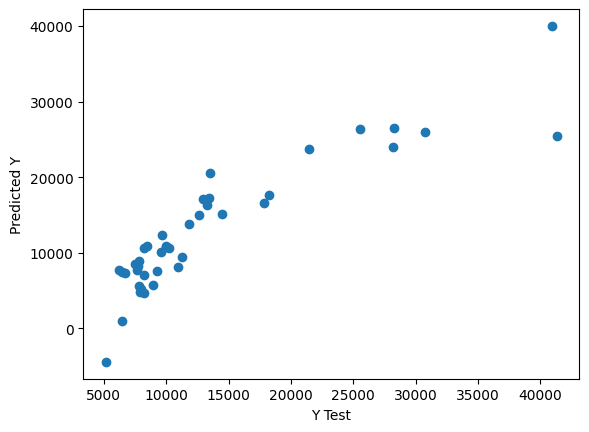

In [107]:
plt.scatter(y_test, predictions)
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')

In [135]:
new_data = pd.DataFrame({
    'symboling': [np.random.randint(-2, 4)],
    'wheelbase': [np.random.uniform(86.6, 120.9)],
    'carlength': [np.random.uniform(141.1, 207)],
    'carwidth': [np.random.uniform(60.3, 71)],
    'carheight': [np.random.uniform(47.8, 58)],
    'curbweight': [np.random.randint(1488, 4065)],
    'enginesize': [np.random.randint(61, 325)],
    'boreratio': [np.random.uniform(2.54, 3)],
    'stroke': [np.random.uniform(2.07, 3)],
    'compressionratio': [np.random.uniform(7, 22)],
    'horsepower': [np.random.randint(48, 287)],
    'peakrpm': [np.random.randint(4150, 6600)],
    'citympg': [np.random.randint(13, 48)],
    'highwaympg': [np.random.randint(16, 53)],
    'fueltype': [np.random.randint(0,1)],
    'doornumber': [np.random.randint(2,3)],
    'carbody': [np.random.randint(0,3)],
    'drivewheel': [np.random.randint(0,3)],
    'enginelocation': [np.random.randint(0,1)],
    'enginetype': [np.random.randint(0,6)],
    'cylindernumber': [np.random.randint(2,12)],
    'fuelsystem': [np.random.randint(0,7)]
}, columns=X_train.columns)


predicted_price = model.predict(new_data)
print(new_data['symboling'][0])
print(new_data['wheelbase'][0])
print(new_data['carlength'][0])
print(new_data['carwidth'][0])
print(new_data['carheight'][0])
print(new_data['curbweight'][0])
print(new_data['enginesize'][0])
print(new_data['boreratio'][0])
print(new_data['stroke'][0])
print(new_data['compressionratio'][0])
print(new_data['horsepower'][0])
print(new_data['peakrpm'][0])
print(new_data['citympg'][0])
print(new_data['highwaympg'][0])
print(new_data['fueltype'][0])
print(new_data['doornumber'][0])
print(new_data['carbody'][0])
print(new_data['drivewheel'][0])
print(new_data['enginelocation'][0])
print(new_data['enginetype'][0])
print(new_data['cylindernumber'][0])
print(new_data['fuelsystem'][0])
print(f"Predicted car price: {predicted_price[0]}")


3
91.76624399010072
202.59617463273628
68.29342258745635
57.31770153047516
2314
163
2.651544749380008
2.5347112554179003
14.6683911134714
87
5803
35
24
0
2
0
2
0
1
3
6
Predicted car price: 18800.195380321333
